<h1>Ablation &amp; Sensitivity analisys<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Resources-used" data-toc-modified-id="Resources-used-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Resources used</a></span></li><li><span><a href="#Loading-validation-results-(vr)" data-toc-modified-id="Loading-validation-results-(vr)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading validation results (vr)</a></span></li><li><span><a href="#Ablation-test" data-toc-modified-id="Ablation-test-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Ablation test</a></span></li><li><span><a href="#Sensitivity-Analisys" data-toc-modified-id="Sensitivity-Analisys-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Sensitivity Analisys</a></span><ul class="toc-item"><li><span><a href="#Hour-of-day-sensitivity" data-toc-modified-id="Hour-of-day-sensitivity-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Hour-of-day sensitivity</a></span></li><li><span><a href="#Type-of-day-sensitivity" data-toc-modified-id="Type-of-day-sensitivity-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Type-of-day sensitivity</a></span><ul class="toc-item"><li><span><a href="#MLFBM-analisys" data-toc-modified-id="MLFBM-analisys-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span>MLFBM analisys</a></span></li><li><span><a href="#CLFBM-analisys" data-toc-modified-id="CLFBM-analisys-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span>CLFBM analisys</a></span></li><li><span><a href="#MAPE-analisys" data-toc-modified-id="MAPE-analisys-4.2.3"><span class="toc-item-num">4.2.3&nbsp;&nbsp;</span>MAPE analisys</a></span></li></ul></li></ul></li><li><span><a href="#Stability-analisys" data-toc-modified-id="Stability-analisys-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Stability analisys</a></span><ul class="toc-item"><li><span><a href="#CLFBM-analisys" data-toc-modified-id="CLFBM-analisys-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>CLFBM analisys</a></span></li><li><span><a href="#MAPE-analisys" data-toc-modified-id="MAPE-analisys-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>MAPE analisys</a></span></li></ul></li></ul></div>

# Resources used

In [1]:
import os
import re
import locale
import requests
import warnings
import calendar
from bs4 import BeautifulSoup
from tqdm.notebook import trange

import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from platform import python_version
import xgboost as xgb
import graphviz
from datetime import time
from datetime import datetime
from datetime import timedelta
import sklearn
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import LearningCurveDisplay

print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")
print(f"XGBoost: v {xgb.__version__}")

python: v 3.10.7
Jupyter Notebook: v 6.4.12
numpy: v 1.25.2
pandas: v 2.2.3
seaborn: v 0.13.2
graphviz: v 0.20.1
matplotlib: v 3.6.2
sklearn: v 1.4.2
XGBoost: v 2.1.2


# Loading validation results (vr)

In [2]:
df_RSV_vs_BR_rate = pd.read_excel('diff_RSV_rate.xlsx')  # penalty tariffs of the System Operator

df_vr_br3_pred = pd.read_excel('Predicted(br_3_pred)Jan_May_2025.xlsx')
df_vr_br3_act = pd.read_excel('Predicted(br_3_act)Jan_May_2025.xlsx')
df_vr_br3_act_LC = pd.read_excel('Predicted(br_3_act)Jan_May_2025_LC(6,6).xlsx')
df_vr_br2_act_LC = pd.read_excel('Predicted(br_2_act)Jan_May_2025_LC(10,5).xlsx')

In [3]:
def added_diff_loss(df, df_RSV_vs_BR_rate):
    
    # add penalty tariffs of the BEM to the final table
    df = df.merge(df_RSV_vs_BR_rate, how='left', on='Date')
    df = df[['Date', 'Month', 'Hour', 'Weekday', 'TypeDay', 'Volume', 'Predicted', 'A_gr_P', 'P_gr_A']]

    # estimate the losses from operating on the BEM
    df['diff_cons'] = df.Volume - df.Predicted
    df['loss'] = np.where(df.diff_cons > 0, 
                          df.diff_cons * df.A_gr_P, 
                          abs(df.diff_cons) * df.P_gr_A)
    return df

In [4]:
df_vr_br3_pred = added_diff_loss(df_vr_br3_pred, df_RSV_vs_BR_rate)
df_vr_br3_act = added_diff_loss(df_vr_br3_act, df_RSV_vs_BR_rate)
df_vr_br3_act_LC = added_diff_loss(df_vr_br3_act_LC, df_RSV_vs_BR_rate)
df_vr_br2_act_LC = added_diff_loss(df_vr_br2_act_LC, df_RSV_vs_BR_rate)

# Ablation test

In [5]:
#df_model_ranking = pd.DataFrame(columns=['MAPE, %', 'MAE, MWh', 'MLFBM, RUR/h', 'MedLFBM, RUR/h', 'CLFBM, RUR'])
df_model_ranking = pd.DataFrame(columns=['MAPE', 'MAE', 'MLFBM', 'MedLFBM', 'CLFBM'])
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']
    
for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    df_model_ranking.loc[models_names[i]] = (round(MAPE(model.Predicted, model.Volume)*100, 3),
                                             round(MAE(model.Predicted, model.Volume), 3),
                                             round(model.loss.mean(), 2),
                                             round(model.loss.median(), 2),
                                             round(model.loss.sum(), 2)
                                            )
    
df_model_ranking = df_model_ranking.sort_values(by=['MAPE'], ascending=False)
df_model_ranking

,MAPE,MAE,MLFBM,MedLFBM,CLFBM
br3_pred,1.464,39.912,4404.41,262.78,15961595.93
br3_act,1.449,39.346,4756.45,223.77,17237365.54
br3_act_LC,1.429,38.992,4527.94,282.37,16409258.49
br2_act_LC,1.411,38.487,4615.36,319.47,16726061.83


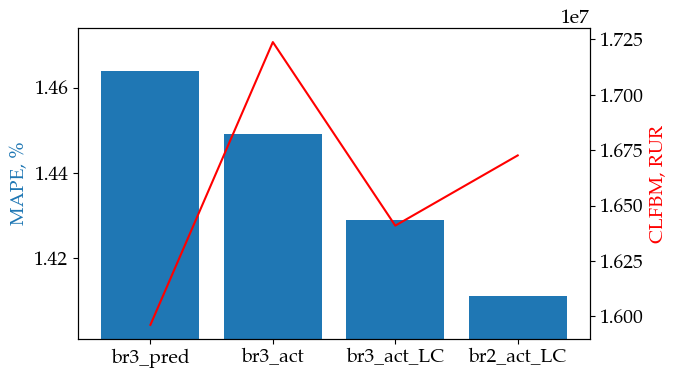

In [8]:
fig, MAPE_score = plt.subplots(figsize=(7, 4))
CLFBM_score = MAPE_score.twinx()
fontsize = 14

plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

MAPE_score.bar(df_model_ranking.index, df_model_ranking.MAPE)
CLFBM_score.plot(df_model_ranking.CLFBM, color='red')

MAPE_score.set_ylim(df_model_ranking.MAPE.min()-0.01, df_model_ranking.MAPE.max()+0.01)
MAPE_score.set_ylabel('MAPE, %', fontsize=fontsize, color='#1f77b4')
#MAPE_score.set_xlabel('Models', fontsize=fontsize+1)
CLFBM_score.set_ylabel('CLFBM, RUR', fontsize=fontsize, color='red')

plt.tight_layout()
plt.savefig('pictures/Ablation.png', dpi = 300, transparent = True, bbox_inches='tight')
    
plt.show()

# Sensitivity Analisys

## Hour-of-day sensitivity

In [198]:
df_hour_of_day = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    hour_of_day = list()
    for hour in range(24):
        hour_of_day.append(model[model.Hour == hour].loss.sum())
    df_hour_of_day[models_names[i]] = hour_of_day
    
df_hour_of_day.head()

,br3_pred,br3_act,br3_act_LC,br2_act_LC
0,615802.759210,546555.750519,553094.192891,515954.277756
1,298532.860082,314024.792437,278052.150518,280400.460118
2,300518.203788,315272.565668,277036.632411,234192.502922
3,492037.561949,416621.874299,387395.142750,437432.313737
4,298316.271763,281128.140650,244156.530722,262461.407923


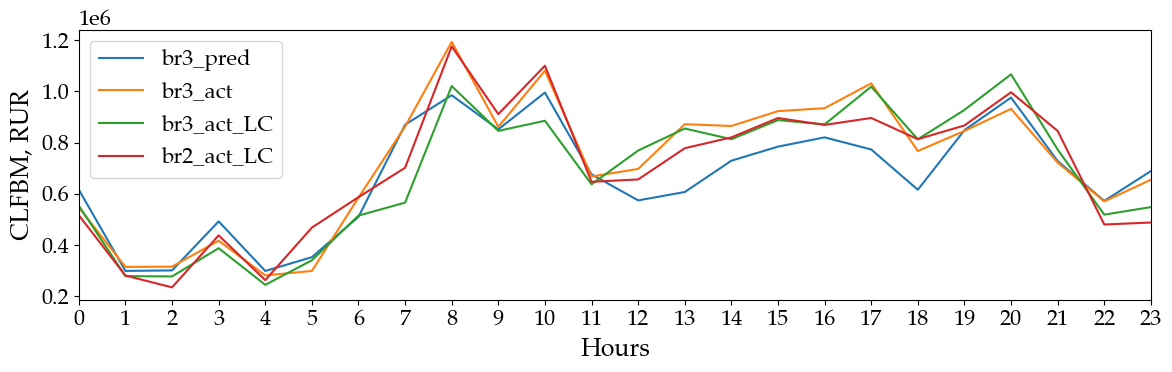

In [191]:
fontsize = 16
plt.figure(figsize=(12, 4))
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

plt.plot(df_hour_of_day.index, df_hour_of_day)
plt.xlim(0, 23)
plt.xticks(ticks=np.arange(0, 24, step=1))
plt.xlabel('Hours', fontsize=fontsize+2)
plt.ylabel('CLFBM, RUR', fontsize=fontsize+2)

plt.legend(df_hour_of_day.columns)

plt.tight_layout()
plt.savefig('pictures/hour-of-day_sensitivity_CLFBM.png', dpi = 300, transparent = True, bbox_inches='tight')
    
plt.show()

In [196]:
df_hour_of_day = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    hour_of_day = list()
    for hour in range(24):

        hour_of_day.append(MAPE(model[model.Hour == hour].Predicted,
                                model[model.Hour == hour].Volume)*100)
        
    df_hour_of_day[models_names[i]] = hour_of_day
    
df_hour_of_day.head()

,br3_pred,br3_act,br3_act_LC,br2_act_LC
0,1.605630,1.716591,1.509724,1.479034
1,1.318526,1.457471,1.253511,1.258083
2,1.411273,1.432969,1.241688,1.193398
3,1.340740,1.339064,1.295481,1.209710
4,1.355247,1.361564,1.258895,1.224192


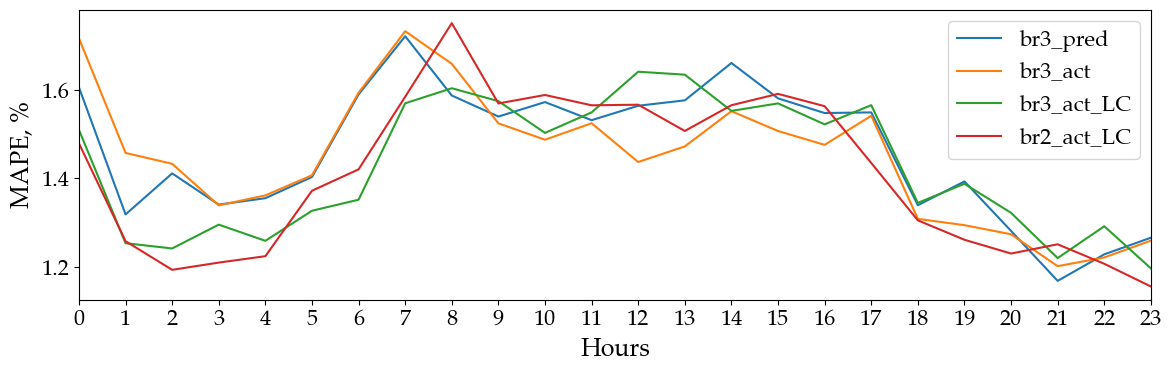

In [194]:
fontsize = 16
plt.figure(figsize=(12, 4))
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

plt.plot(df_hour_of_day.index, df_hour_of_day)
plt.xlim(0, 23)
plt.xticks(ticks=np.arange(0, 24, step=1))
plt.xlabel('Hours', fontsize=fontsize+2)
plt.ylabel('MAPE, %', fontsize=fontsize+2)

plt.legend(df_hour_of_day.columns)

plt.tight_layout()
plt.savefig('pictures/hour-of-day_sensitivity_MAPE.png', dpi = 300, transparent = True, bbox_inches='tight')
    
plt.show()

## Type-of-day sensitivity

### MLFBM analisys

In [199]:
df_type_of_day = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    type_of_day = list()
    for typeDay in range(4):
        #type_of_day.append(model[model.TypeDay == typeDay].loss.sum())
        type_of_day.append(model[model.TypeDay == typeDay].loss.mean())
    df_type_of_day[models_names[i]] = type_of_day
    
df_type_of_day

,br3_pred,br3_act,br3_act_LC,br2_act_LC
0,5047.066415,5512.498717,5006.672962,5242.302957
1,5430.207091,4743.633666,4680.767601,5033.695657
2,3875.845800,3634.083397,3611.939168,3978.452435
3,2983.472347,3307.673403,3668.984459,3297.481498


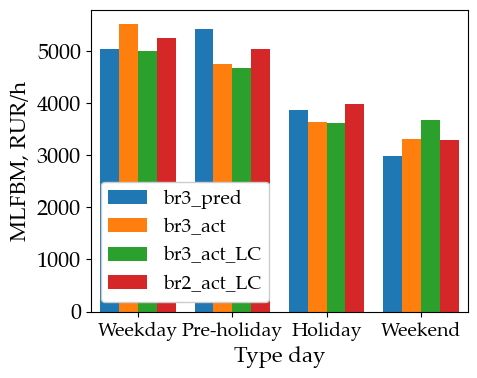

In [200]:
fontsize = 14
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

type_days = ('Weekday', 'Pre-holiday', 'Holiday', 'Weekend')

width = 0.2
multiplier = 0
x = np.arange(len(df_type_of_day))  # the label locations

for i, column in enumerate(df_type_of_day.columns):
    offset = width * multiplier
    rects = ax.bar(x + offset - 0.1, df_type_of_day[column], width, label=column, alpha=1)
    multiplier += 1     
    
ax.set_xlim(-0.3, len(df_type_of_day)-0.3)
ax.set_xticks(x + width, type_days, fontsize=fontsize)
ax.set_xlabel('Type day', fontsize=fontsize+2)
ax.set_ylabel('MLFBM, RUR/h', fontsize=fontsize+2)

ax.legend(fontsize=fontsize, 
          loc='lower left', 
          framealpha=1)
plt.tight_layout()
plt.savefig('pictures/type-of-day_sensitivity_MLFBM.png', dpi = 300, transparent = True, bbox_inches='tight')
plt.show()

### CLFBM analisys

In [202]:
df_type_of_day = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    type_of_day = list()
    for typeDay in range(4):
        type_of_day.append(model[model.TypeDay == typeDay].loss.sum())
    df_type_of_day[models_names[i]] = type_of_day
    
df_type_of_day

,br3_pred,br3_act,br3_act_LC,br2_act_LC
0,1.162844e+07,1.270080e+07,1.153537e+07,1.207827e+07
1,2.606499e+05,2.276944e+05,2.246768e+05,2.416174e+05
2,1.205388e+06,1.130200e+06,1.123313e+06,1.237299e+06
3,2.867117e+06,3.178674e+06,3.525894e+06,3.168880e+06


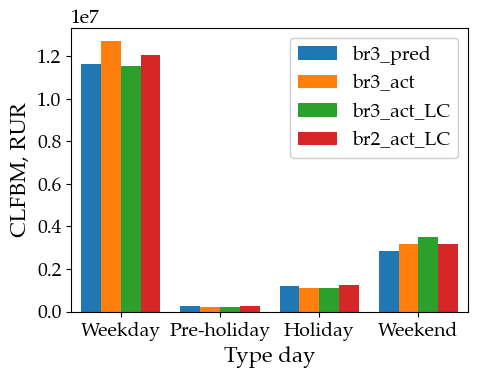

In [204]:
fontsize = 14
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

type_days = ('Weekday', 'Pre-holiday', 'Holiday', 'Weekend')

width = 0.2
multiplier = 0
x = np.arange(len(df_type_of_day))  # the label locations

for i, column in enumerate(df_type_of_day.columns):
    offset = width * multiplier
    rects = ax.bar(x + offset - 0.1, df_type_of_day[column], width, label=column, alpha=1)
    multiplier += 1     
    
ax.set_xlim(-0.3, len(df_type_of_day)-0.3)
ax.set_xticks(x + width, type_days, fontsize=fontsize)
ax.set_xlabel('Type day', fontsize=fontsize+2)
ax.set_ylabel('CLFBM, RUR', fontsize=fontsize+2)

ax.legend(fontsize=fontsize, 
          #loc='lower left', 
          framealpha=1)
plt.tight_layout()
plt.savefig('pictures/type-of-day_sensitivity_CLFBM.png', dpi = 300, transparent = True, bbox_inches='tight')
plt.show()

### MAPE analisys

In [187]:
df_type_of_day = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    type_of_day = list()
    for typeDay in range(4):
        #type_of_day.append(model[model.TypeDay == typeDay].loss.sum())
        type_of_day.append(MAPE(model[model.TypeDay == typeDay].Predicted,
                                model[model.TypeDay == typeDay].Volume)*100)
        
    df_type_of_day[models_names[i]] = type_of_day
    
df_type_of_day

,br3_pred,br3_act,br3_act_LC,br2_act_LC
0,1.435676,1.412404,1.424028,1.381052
1,2.603396,2.612777,2.220934,2.167282
2,1.960741,1.938377,1.890405,1.834478
3,1.313530,1.320854,1.250391,1.306255


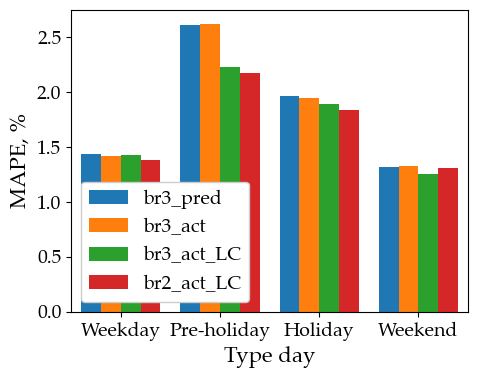

In [189]:
fontsize = 14
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

type_days = ('Weekday', 'Pre-holiday', 'Holiday', 'Weekend')

width = 0.2
multiplier = 0
x = np.arange(len(df_type_of_day))  # the label locations

for i, column in enumerate(df_type_of_day.columns):
    offset = width * multiplier
    rects = ax.bar(x + offset - 0.1, df_type_of_day[column], width, label=column, alpha=1)
    multiplier += 1     
    
ax.set_xlim(-0.3, len(df_type_of_day)-0.3)
ax.set_xticks(x + width, type_days, fontsize=fontsize)
ax.set_xlabel('Type day', fontsize=fontsize+2)
ax.set_ylabel('MAPE, %', fontsize=fontsize+2)

ax.legend(fontsize=fontsize, 
          loc='lower left', 
          framealpha=1)
plt.tight_layout()
plt.savefig('pictures/type-of-day_sensitivity_MAPE.png', dpi = 300, transparent = True, bbox_inches='tight')
plt.show()

# Stability analisys

## CLFBM analisys

In [208]:
df_months = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    months_list = list()
    for month in range(1, 6):
        months_list.append(model[model.Month == month].loss.sum())
    df_months[models_names[i]] = months_list
    
df_months.index = df_months.index + 1
df_months

,br3_pred,br3_act,br3_act_LC,br2_act_LC
1,2.402477e+06,2.542388e+06,2.573455e+06,2.914162e+06
2,1.446752e+06,1.402013e+06,1.669133e+06,1.781954e+06
3,1.269875e+06,1.378811e+06,1.174493e+06,1.117530e+06
4,2.630679e+06,2.554488e+06,2.330778e+06,2.395196e+06
5,8.211365e+06,9.359666e+06,8.661400e+06,8.517220e+06


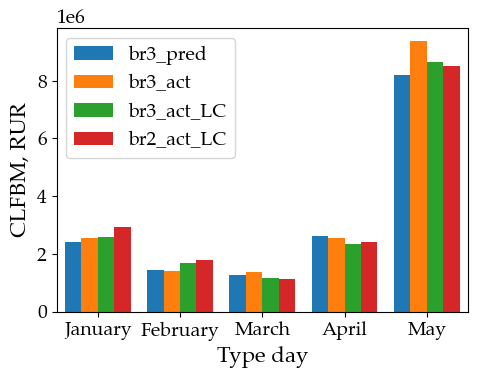

In [209]:
fontsize = 14
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

width = 0.2
multiplier = 0
x = np.arange(len(df_months))  # the label locations

for i, column in enumerate(df_months.columns):
    offset = width * multiplier
    rects = ax.bar(x + offset - 0.1, df_months[column], width, label=column, alpha=1)
    multiplier += 1     
    
ax.set_xlim(-0.3, len(df_months)-0.3)
ax.set_xticks(x + width, calendar.month_name[1:6], fontsize=fontsize)
ax.set_xlabel('Type day', fontsize=fontsize+2)
ax.set_ylabel('CLFBM, RUR', fontsize=fontsize+2)

ax.legend(fontsize=fontsize)
plt.tight_layout()
plt.savefig('pictures/months_sensitivity_CLFBM.png', dpi = 300, transparent = True, bbox_inches='tight')
plt.show()

## MAPE analisys

In [211]:
df_months = pd.DataFrame()
models_names = ['br3_pred', 'br3_act', 'br3_act_LC', 'br2_act_LC']

for i, model in enumerate([df_vr_br3_pred, df_vr_br3_act, df_vr_br3_act_LC, df_vr_br2_act_LC]):
    months_list = list()
    for month in range(1, 6):
        
        months_list.append(MAPE(model[model.Month == month].Predicted,
                                model[model.Month == month].Volume)*100)
        
    df_months[models_names[i]] = months_list
    
df_months.index = df_months.index + 1
df_months

,br3_pred,br3_act,br3_act_LC,br2_act_LC
1,1.605043,1.576125,1.639515,1.636394
2,1.233427,1.245751,1.195664,1.241621
3,1.169015,1.180694,1.103869,1.121548
4,1.688794,1.619014,1.569727,1.489525
5,1.609770,1.609206,1.617530,1.548083


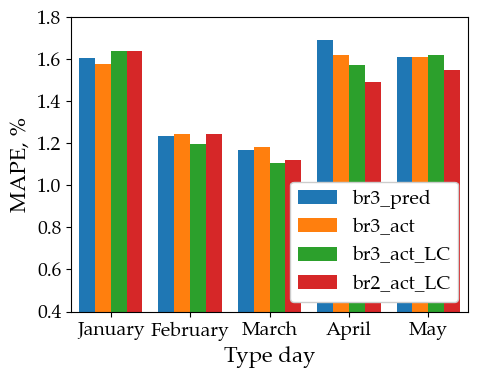

In [224]:
fontsize = 14
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = fontsize

width = 0.2
multiplier = 0
x = np.arange(len(df_months))  # the label locations

for i, column in enumerate(df_months.columns):
    offset = width * multiplier
    rects = ax.bar(x + offset - 0.1, df_months[column], width, label=column, alpha=1)
    multiplier += 1     
    
ax.set_xlim(-0.3, len(df_months)-0.3)
ax.set_ylim(0.4, 1.8)
ax.set_xticks(x + width, calendar.month_name[1:6], fontsize=fontsize)
ax.set_xlabel('Type day', fontsize=fontsize+2)
ax.set_ylabel('MAPE, %', fontsize=fontsize+2)

ax.legend(fontsize=fontsize, loc='lower right', framealpha=1)
plt.tight_layout()
plt.savefig('pictures/months_sensitivity_MAPE.png', dpi = 300, transparent = True, bbox_inches='tight')
plt.show()